In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
import pandas as pd

# Simulation details

I first define the internal units for the simulation. I want it to be similar to a star and I want to use $N \sim 80-100$ particles, so I will set $1 \ M[IU] = 0.01 \ M_\odot = 2 \times 10^{31} \ g$ and $L \ [IU] = 1 \ R_\odot = 7 \times 10^{10} \ cm$. The time unit will be $T \ [IU] = 16035 \ s$. I will use a precision d=0.01 and print a timestamp every 0.01 IU.

# Inverse transform sampling

The pdf to sample from has the following form:

$p(\vec{x}) \propto r^2 sin(\theta) $ 

so, uniform in $\phi$, but not in $r$ and $\theta$. This is just the product of distinct distributions $p(\vec{x})=p_1(r) \cdot p_2(\theta) \cdot p_3(\phi)$. I want to sample $r \in [0.1, 2]$, $\theta \in [0, \pi]$ and $\phi \in [0, 2\pi]$. Therefore to normalize I will set:

$p_1(r) = \frac{3}{8-0.1^3} \cdot r^2$

$p_2(\theta) = \frac{1}{2} sin(\theta)$

$p_3(\phi) = \frac{1}{2\pi}$

The CDF can be computed analytically in all cases:

$H_1(r)=\frac{r^3}{8-0.1^3}$

$H_2(\theta)=-\frac{1}{2}cos(\theta)+\frac{1}{2}$

$H_3(\phi)=\frac{1}{2\pi}\phi$

So that:

$r = [(8-0.1^3)\cdot H_1]^{\frac{1}{3}}$

$\theta = arccos(1-2H_2)$

$\phi=2\pi H_3$

Now let's sample and invert.

In [19]:
N_points = 80

y1 = uniform.rvs(0, 1, N_points)
y2 = uniform.rvs(loc=0, scale=1, size=N_points)
y3 = uniform.rvs(loc=0, scale=1, size=N_points)

r = (y1 * (8-0.1**3)) ** (1/3)
theta = np.arccos(1 - 2 * y2)
phi = 2*np.pi*y3

Text(0.5, 0, 'r [UI]')

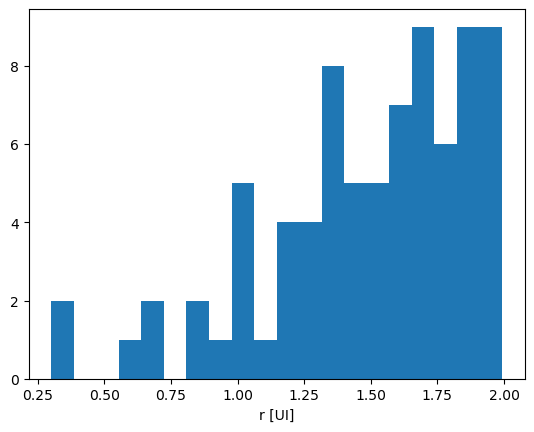

In [20]:
fig, ax = plt.subplots()
plt.hist(r, bins=20)
plt.xlabel('r [UI]')

Text(0.5, 0, '$\\theta \\ [rad]$')

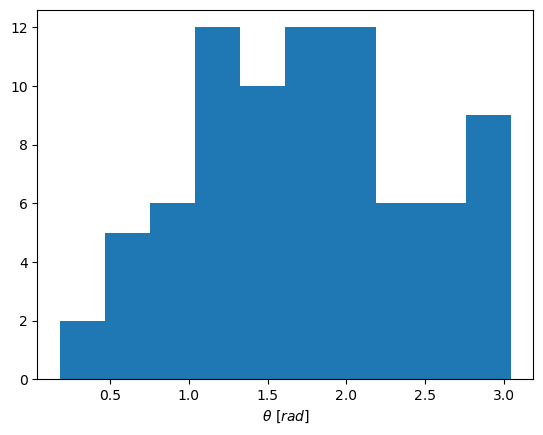

In [21]:
plt.hist(theta)
plt.xlabel(r'$\theta \ [rad]$')

Text(0.5, 0, '$\\phi \\ [rad]$')

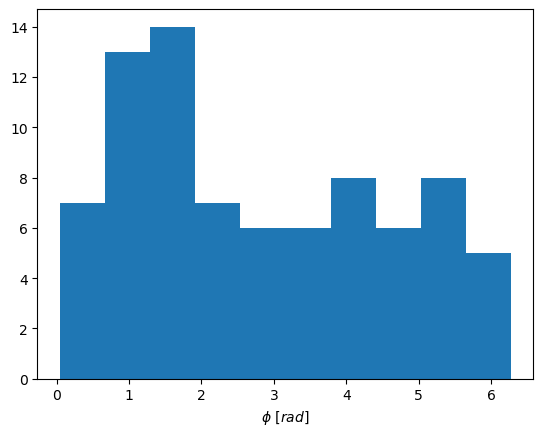

In [22]:
plt.hist(phi)
plt.xlabel(r'$\phi \ [rad]$')

Now let's turn this into (x, y, z) points and fill the initial conditions file, giving each particle a mass of 1 IU.

In [23]:
def spher_to_xyz(radius, t, p):
    x = radius * np.sin(t) * np.cos(p)
    y = radius * np.sin(t) * np.sin(p)
    z = radius * np.cos(t)
    return x, y, z

In [24]:
x_list, y_list, z_list = spher_to_xyz(r, theta, phi)
vx = np.zeros(N_points)
vy = np.zeros(N_points)
vz = np.zeros(N_points)
mass = np.ones(N_points)

# Set up initial conditions

In [25]:
cond_dict = {'m': mass, 'x': x_list, 'y': y_list, 'z': z_list, 'vx': vx, 'vy': vy, 'vz': vz}

In [61]:
def write_ic_in_file(filename, ic_dict, t0=0.0):
    '''
    filename = name of the file where you want the initial conditions
    ic_dict = dictionary containing mass, position and velocity of each particle
    t0 = start time (default=0)
    '''
    N_iter = len(ic_dict['x'])
    
    with open(filename, 'w') as f:  #first say the number of particles and the start time
        f.write(str(N_iter)+'\n')
        f.write(f"{t0:.16e}\n")
        f.close()
    
    for i in range(N_iter):
        x = ic_dict["x"][i]
        y = ic_dict['y'][i]
        z = ic_dict['z'][i]
        vx = ic_dict['vx'][i]
        vy = ic_dict['vy'][i]
        vz = ic_dict['vz'][i]
        m = ic_dict['m'][i]

        with open(filename, 'a') as f:   #append the lines; opening with 'w' overwrites the previous information
            f.write(
            f"{m:.16e} {x:.16e} {y:.16e} {z:.16e} "
            f"{vx:.16e} {vy:.16e} {vz:.16e}\n"
        )

    print('Initial conditions updated. Check your txt file.')

In [60]:
file_path = 'spher_shell_IC.txt'

write_ic_in_file(file_path, cond_dict)

Initial conditions updated. Check your txt file.


# Actual simulation & results

I estimate the collapse time to be: $T_{coll}=\sqrt{\frac{3\pi}{32G\rho_0}}$ where $\rho_0=\frac{\sum_i m_i}{V} \ (i=1...N) = 2.388 \ [IU]$, so that $T_{coll}=0.35 \ [IU]$. 

Does the simulation agree? I will let it run a little longer than the estimated collapse time, just in case.
Maybe I will change it, but for now I will assume that the distribution has collapsed when the mean r reaches its smallest value.

In [26]:
output_path = 'spher_shell_out.txt'

In [27]:
def xyz_to_r(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    return r

In [90]:
data = pd.read_csv(output_path, sep=' ', header=None, names=range(7))
data.columns = ['m','x','y','z','vx','vy','vz']

time_rows = data[data.index % 82 -1 == 0]
times = (time_rows['m']) #only in the 1st lines m is the timestamp, the other 80 times it's the mass of each particle

In [30]:
print(data)

             m         x         y         z        vx        vy        vz
0    80.000000       NaN       NaN       NaN       NaN       NaN       NaN
1     0.100106       NaN       NaN       NaN       NaN       NaN       NaN
2     1.000000 -0.332612  0.331980 -1.162535  1.648857 -0.608462  0.300056
3     1.000000 -0.837263  1.074587  0.707702 -0.735342 -0.971679 -2.320362
4     1.000000  0.166923 -0.177445  1.513349  0.356205 -0.913319 -1.787937
..         ...       ...       ...       ...       ...       ...       ...
487   1.000000  2.460015 -1.128015 -0.670064  9.252732 -3.488473 -4.319750
488   1.000000  0.931345 -1.173077 -0.288298  1.175213 -5.555451 -1.125071
489   1.000000 -0.657654 -0.033767  0.214816 -0.750966 -3.275189  6.309788
490   1.000000 -0.896754  0.664455  1.812408 -3.718776  1.401077  6.278848
491   1.000000  0.322168  0.178594 -1.164630 -5.282268  0.855573 -6.401589

[492 rows x 7 columns]


In [92]:
# for every timestamp, compute the positions of the particles.

r_values = []

for i in range(len(times)):
    
    r_timestamp = 0
    
    for j in range(N_points):
        particle_rows = data[data.index % 82 - (2+j) == 0]
        x = particle_rows['x'][82*i + j+2]
        y = particle_rows['y'][82*i + j+2]
        z = particle_rows['z'][82*i + j+2]
        r = xyz_to_r(x, y, z)
        r_timestamp+=r

    mean_r = r_timestamp/N_points
    r_values.append(mean_r)

In [93]:
print(r_values)

[np.float64(1.4628166563887095), np.float64(1.4604035640663169), np.float64(1.4565297005645492), np.float64(1.451173606708562), np.float64(1.4442442449936044), np.float64(1.4357391618698714), np.float64(1.4257011679403129), np.float64(1.4140600919186286), np.float64(1.400907175014963), np.float64(1.3861359184174897), np.float64(1.3697198849932166), np.float64(1.3516311434705939), np.float64(1.3318963253471923), np.float64(1.3103900253687728), np.float64(1.2869246932576262), np.float64(1.2619355860956993), np.float64(1.234859312084242), np.float64(1.2058874568326998), np.float64(1.1749237294861952), np.float64(1.1418790009124762), np.float64(1.1068019887208072), np.float64(1.0695569485111935), np.float64(1.0302661181160606), np.float64(0.9888403332373057), np.float64(0.9451329470384614), np.float64(0.8988596918052215), np.float64(0.8498604343429437), np.float64(0.7978213591942659), np.float64(0.7427763504767261), np.float64(0.6849297415187509), np.float64(0.6239227141403125), np.float64

Text(0, 0.5, 'Mean r [IU]')

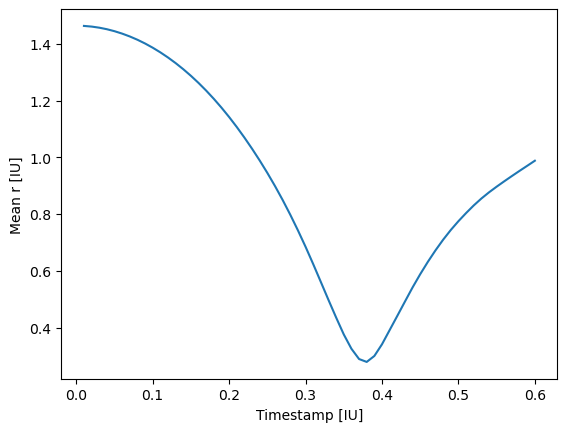

In [99]:
fig, ax = plt.subplots()
plt.plot(times, r_values)
plt.xlabel('Timestamp [IU]')
plt.ylabel('Mean r [IU]')

In [97]:
sorted_idxs = np.argsort(r_values)
min_idx = sorted_idxs[0]
min_time = times[min_idx*82+1]
print(min_time)

0.3800012633346266


"Only" a 0.03 difference in IU: not too bad.